# Loan Approval Dataset: Exploratory Data Analysis

This notebook explores the labeled training split from the Analytics Vidhya Loan Prediction practice problem. The original CSV is kept unchanged in `ml/data/raw/`; every analysis below reads it as-is. The practice dataset describes historical home-loan applications, not a representative or current lending population, so its patterns should not be treated as causal or used as lending policy.

**Scope:** understand the data, quality, distributions, possible outliers, target balance, and numeric relationships. This is EDA only: there is no cleaning, feature engineering, preprocessing, or model training.

## 1. Load the raw dataset

Start with the untouched labeled training file. Resolving the path from either the project root or this notebook's directory makes the notebook convenient to run in both locations. Imports are limited to tools used for tabular summaries and plots.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
DATA_FILENAME = "train_u6lujuX_CVtuZ9i.csv"
candidate_paths = [
    Path.cwd() / "ml" / "data" / "raw" / DATA_FILENAME,
    Path.cwd().parent / "data" / "raw" / DATA_FILENAME,
]
DATA_PATH = next((path for path in candidate_paths if path.is_file()), None)
if DATA_PATH is None:
    searched = "\n".join(str(path) for path in candidate_paths)
    raise FileNotFoundError(f"Could not find the raw dataset. Checked:\n{searched}")

# Read the source file once; all later exploratory work uses separate summaries.
df = pd.read_csv(DATA_PATH)
print(f"Loaded {DATA_PATH}")
print(f"Raw CSV shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded C:\Users\Dell\AI-Loan-Risk-Prediction\ml\data\raw\train_u6lujuX_CVtuZ9i.csv
Raw CSV shape: 614 rows x 13 columns


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 2. Shape, columns, and data types

The dimensions show how many applications and fields are available. Column names and inferred types help distinguish identifiers, numeric measurements, categories, and the approval outcome before interpreting summaries.

In [2]:
print("Column names:")
print(df.columns.tolist())
print("\nInferred data types:")
display(df.dtypes.rename("dtype").to_frame())
print("\nDataFrame info:")
df.info()

Column names:
['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Inferred data types:


,dtype
Loan_ID,str
Gender,str
Married,str
Dependents,str
Education,str
Self_Employed,str
ApplicantIncome,int64
CoapplicantIncome,float64
LoanAmount,float64
Loan_Amount_Term,float64



DataFrame info:
<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


## 3. Missing values

Missing-value counts and percentages identify fields that need attention in a later preprocessing phase. The chart displays only columns with missing entries. No missing values are filled or removed in this notebook.

,missing_count,missing_percent
Credit_History,50,8.14
Self_Employed,32,5.21
LoanAmount,22,3.58
Dependents,15,2.44
Loan_Amount_Term,14,2.28
Gender,13,2.12
Married,3,0.49


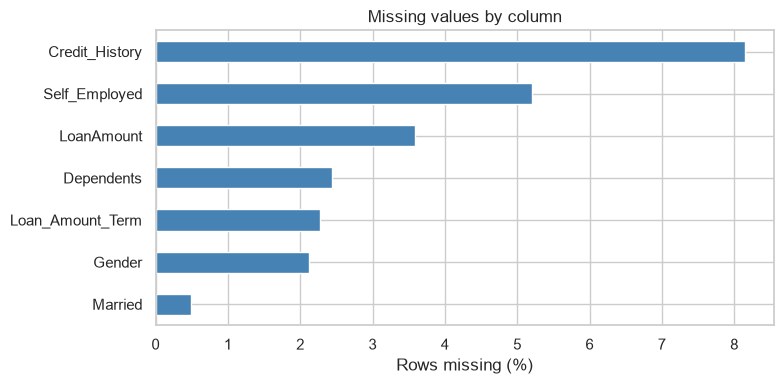

In [3]:
missing = pd.DataFrame({
    # Keep both counts and percentages so columns can be compared fairly.
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean().mul(100),
}).sort_values("missing_count", ascending=False)
display(missing[missing["missing_count"] > 0].round(2))

missing_to_plot = missing.loc[missing["missing_count"] > 0, "missing_percent"]
if missing_to_plot.empty:
    print("No missing values found.")
else:
    ax = missing_to_plot.sort_values().plot.barh(figsize=(8, 4), color="steelblue")
    ax.set(title="Missing values by column", xlabel="Rows missing (%)", ylabel="")
    plt.tight_layout()
    plt.show()

## 4. Duplicate records

Exact duplicate rows may repeat the same application and affect later analyses. The application identifier is also checked separately for repeated values. These are diagnostics only; records are not dropped.

In [4]:
print(f"Exact duplicate rows: {df.duplicated().sum()}")
if "Loan_ID" in df.columns:
    print(f"Repeated Loan_ID values: {df['Loan_ID'].duplicated().sum()}")

Exact duplicate rows: 0
Repeated Loan_ID values: 0


## 5. Numerical features

Summary statistics give the scale, spread, and quartiles of numeric fields. Histograms show distribution shape; skewed income or loan amounts can make the mean differ substantially from a typical observation. `Credit_History` is a numeric 0/1 indicator, so it is described as a category rather than a continuous measurement.

,count,mean,std,min,25%,50%,75%,max
ApplicantIncome,614.0,5403.46,6109.04,150.0,2877.5,3812.5,5795.00,81000.0
CoapplicantIncome,614.0,1621.25,2926.25,0.0,0.0,1188.5,2297.25,41667.0
LoanAmount,592.0,146.41,85.59,9.0,100.0,128.0,168.00,700.0
Loan_Amount_Term,600.0,342.00,65.12,12.0,360.0,360.0,360.00,480.0


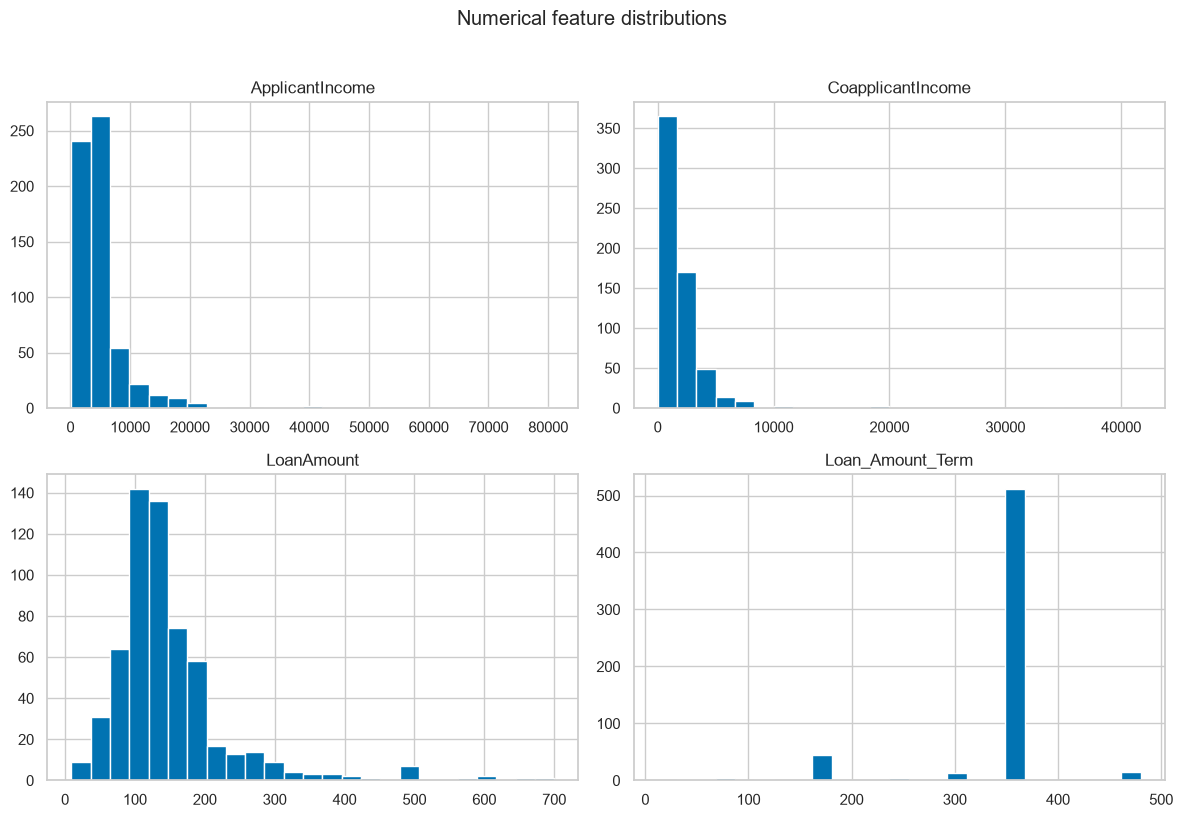

In [5]:
continuous_features = [
    "ApplicantIncome",
    "CoapplicantIncome",
    "LoanAmount",
    "Loan_Amount_Term",
]
continuous_features = [column for column in continuous_features if column in df.columns]
display(df[continuous_features].describe().T.round(2))

df[continuous_features].hist(bins=25, figsize=(12, 8), edgecolor="white")
plt.suptitle("Numerical feature distributions", y=1.02)
plt.tight_layout()
plt.show()

## 6. Categorical features

Category counts show how observations are distributed among applicant and property groups. Missing values are kept visible in the counts. `Loan_ID` is an identifier and is excluded because its labels are not meaningful categories for comparing applicants.


Gender (3 categories):


C:\Users\Dell\AppData\Local\Temp\ipykernel_26748\2087290276.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  column for column in df.select_dtypes(include=["object", "category"]).columns


,count
Gender,
Male,489
Female,112
NaN,13



Married (3 categories):


,count
Married,
Yes,398
No,213
NaN,3


...

,count
Education,
Graduate,480
Not Graduate,134



Self_Employed (3 categories):


,count
Self_Employed,
No,500
Yes,82
NaN,32



Property_Area (3 categories):


,count
Property_Area,
Semiurban,233
Urban,202
Rural,179


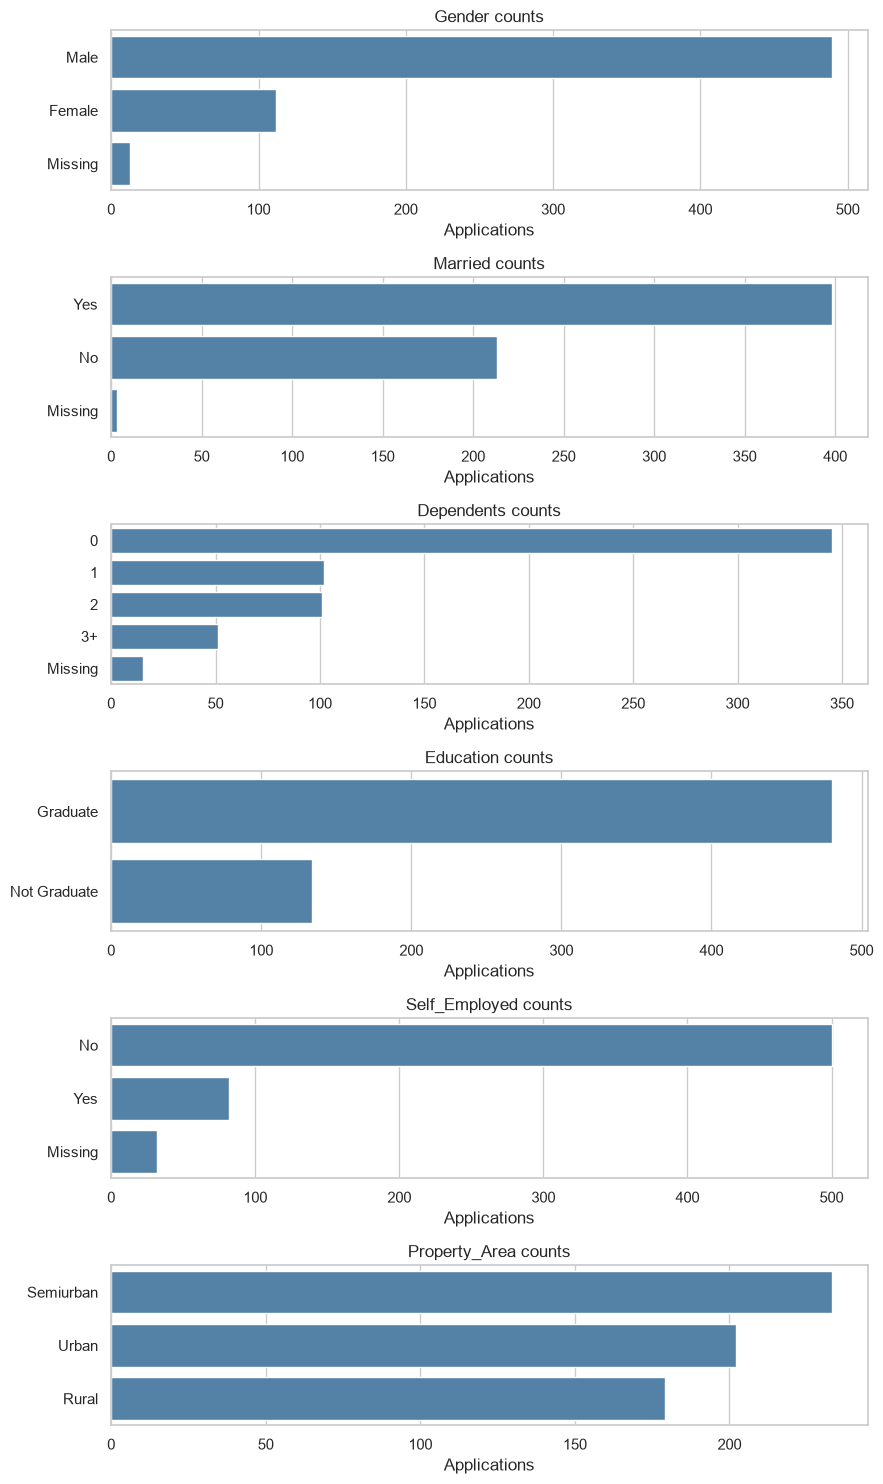

In [6]:
categorical_features = [
    column for column in df.select_dtypes(include=["object", "category"]).columns
    if column not in {"Loan_ID", "Loan_Status"}
]
for column in categorical_features:
    print(f"\n{column} ({df[column].nunique(dropna=False)} categories):")
    display(df[column].value_counts(dropna=False).rename("count").to_frame())

if categorical_features:
    fig, axes = plt.subplots(
        len(categorical_features), 1,
        figsize=(9, max(3, 2.5 * len(categorical_features))),
        squeeze=False,
    )
    for ax, column in zip(axes[:, 0], categorical_features):
        # Label missing categories for plotting without changing the source column.
        plot_counts = df[column].astype("string").fillna("Missing").value_counts()
        sns.barplot(x=plot_counts.values, y=plot_counts.index, ax=ax, color="steelblue")
        ax.set(title=f"{column} counts", xlabel="Applications", ylabel="")
    plt.tight_layout()
    plt.show()

## 7. Target distribution

`Loan_Status` is the historical approval label (`Y` or `N`). Counts and percentages reveal class balance; a majority class is important context for any future evaluation. This step describes the existing labels and does not fit a model.

,count,percent
Loan_Status,,
Y,422,68.73
N,192,31.27


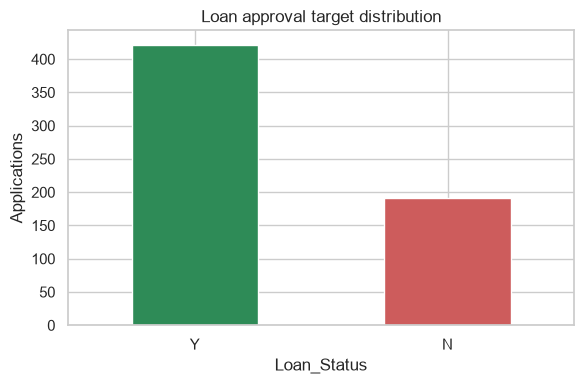

In [7]:
target = "Loan_Status"
if target not in df.columns:
    raise KeyError(f"Expected target column {target!r} was not found.")
target_counts = df[target].value_counts(dropna=False)
target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_counts.div(len(df)).mul(100),
})
display(target_summary.round(2))

ax = target_counts.plot.bar(figsize=(6, 4), color=["seagreen", "indianred"])
ax.set(title="Loan approval target distribution", xlabel="Loan_Status", ylabel="Applications")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

## 8. Outlier analysis

The interquartile-range (IQR) rule flags unusually distant numeric observations for review; a flag is not proof of an error, especially for income and loan amounts. Box plots make the long tails visible. This analysis does not cap, remove, or otherwise alter any value.

,lower_IQR_bound,upper_IQR_bound,flagged_count,flagged_percent_of_nonmissing
feature,,,,
ApplicantIncome,-1498.75,10171.25,50,8.14
CoapplicantIncome,-3445.88,5743.12,18,2.93
LoanAmount,-2.00,270.00,39,6.59
Loan_Amount_Term,360.00,360.00,88,14.67


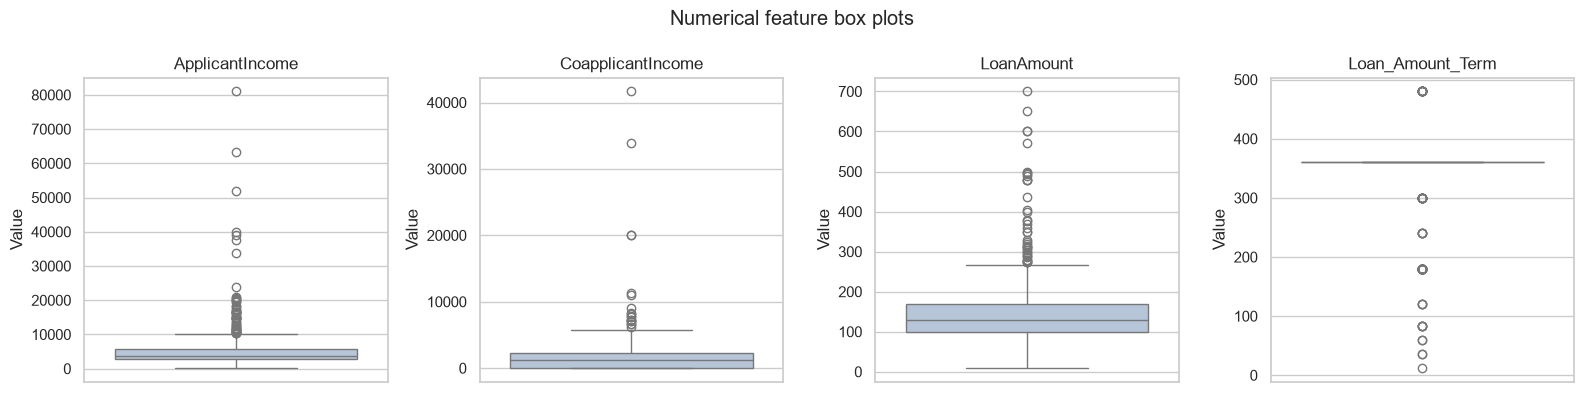

In [8]:
outlier_rows = []
for column in continuous_features:
    values = df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    # IQR flags guide review; they are not a rule for deleting observations.
    flagged = values[(values < lower_bound) | (values > upper_bound)]
    outlier_rows.append({
        "feature": column,
        "lower_IQR_bound": lower_bound,
        "upper_IQR_bound": upper_bound,
        "flagged_count": len(flagged),
        "flagged_percent_of_nonmissing": len(flagged) / len(values) * 100,
    })
display(pd.DataFrame(outlier_rows).set_index("feature").round(2))

fig, axes = plt.subplots(1, len(continuous_features), figsize=(4 * len(continuous_features), 4))
for ax, column in zip(np.atleast_1d(axes), continuous_features):
    sns.boxplot(y=df[column], ax=ax, color="lightsteelblue")
    ax.set(title=column, ylabel="Value")
fig.suptitle("Numerical feature box plots")
plt.tight_layout()
plt.show()

## 9. Numeric correlation

Pearson correlations summarize linear relationships among numeric measurements and the binary credit-history indicator. For a limited exploratory view of the target, `Y` and `N` are represented in a temporary series as 1 and 0; the original dataframe and CSV are not changed. Correlation is descriptive, does not imply causation, and does not encode the unordered text categories.

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status (Y=1)
ApplicantIncome,1.00,-0.12,0.57,-0.05,-0.01,-0.00
CoapplicantIncome,-0.12,1.00,0.19,-0.06,-0.00,-0.06
LoanAmount,0.57,0.19,1.00,0.04,-0.01,-0.04
Loan_Amount_Term,-0.05,-0.06,0.04,1.00,0.00,-0.02
Credit_History,-0.01,-0.00,-0.01,0.00,1.00,0.56
Loan_Status (Y=1),-0.00,-0.06,-0.04,-0.02,0.56,1.00


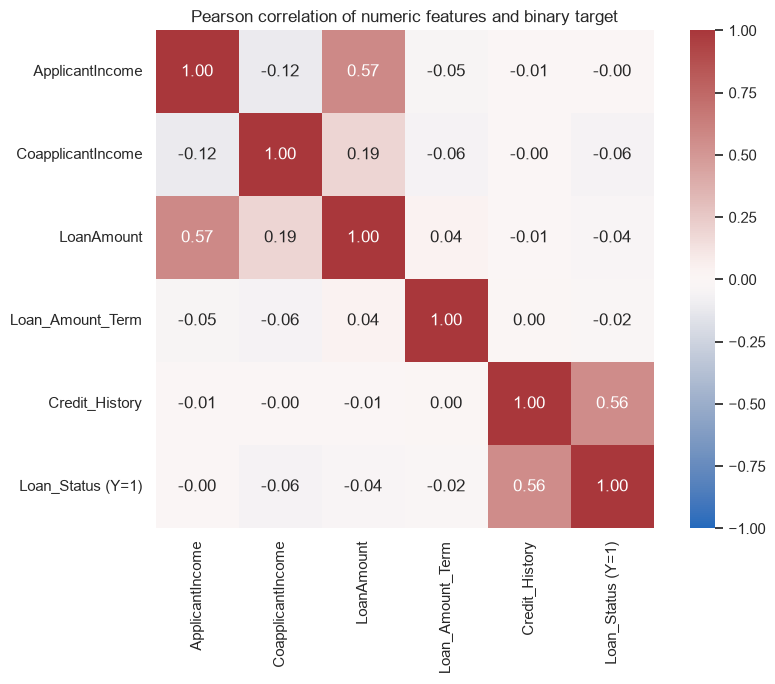

In [9]:
correlation_features = continuous_features.copy()
if "Credit_History" in df.columns:
    correlation_features.append("Credit_History")
correlation_data = df[correlation_features].copy()
# Encode only a temporary target series so the original labels stay untouched.
target_binary = df[target].map({"N": 0, "Y": 1})
if target_binary.notna().any():
    correlation_data["Loan_Status (Y=1)"] = target_binary
correlation_matrix = correlation_data.corr(method="pearson")
display(correlation_matrix.round(2))

plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
)
plt.title("Pearson correlation of numeric features and binary target")
plt.tight_layout()
plt.show()

## 10. EDA takeaways and limitations

Use the printed summaries and charts above to record data-quality and distribution observations before beginning a later phase. In particular, note missingness, class imbalance, skew, and any IQR flags that warrant investigation rather than automatic removal. This small practice dataset is historical and its approval outcomes may reflect context and decision processes not represented in the recorded fields; descriptive relationships are not causal or fairness assessments.